In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from openpyxl import load_workbook
from numba import jit

In [21]:
# Define the boundary and well radius
l = 4.0
r_out = 0.9
r_in = 0.1     #well radius
b = r_out
depth=0         #depth=0:original Try different depth values
w_h = 9.0 + depth   #well height
cap = 9.0 + depth   #cap height
fps = 30
# Define the diffusion coefficient and beta value
r_bead = 0.1
D_0 = 1.005
r_0 = 0.1
k = D_0*r_0
D = k/r_bead
beta = 3.0
epsilon = 0.9
dt = 1e-4

# Define the step size and the total simulation time
dx = dy = dz = 0.04

# Choose the excel file to save data
path = "./Excel/"+str(D)+'_'+str(fps)+'Hz_depth='+str(depth)+'step_size='+str(dx)+'dt='+str(dt)+'_angle_wander_MonteCarlo.xlsx'
print(path)

./Excel/1.005_30Hz_depth=0step_size=0.04dt=0.0001_angle_wander_MonteCarlo.xlsx


Text(0.5, 1.0, 'Geometric well')

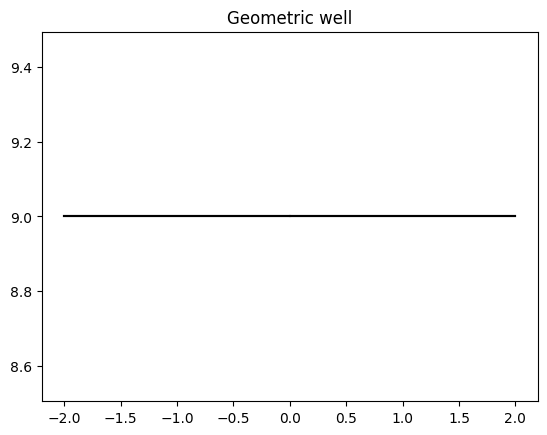

In [22]:
import warnings
# Well
@jit(nopython=True)
def well_z(r):  
    return (r >= 0)*w_h
@jit(nopython=True)
def well_r(z_pos):
    return r_out
r_span= np.linspace(0, l//2, 100)
z_span= np.linspace(0, w_h, 100)
plt.plot(r_span,well_z(r_span),color="black")
plt.plot(-r_span,well_z(r_span),color="black")
plt.plot([-l//2,l//2],[cap,cap],color="black")
plt.title("Geometric well")
#plt.plot(z_span,well_r(z_span))

Maximum dwell time at log10(t) = -0.8894618072532053


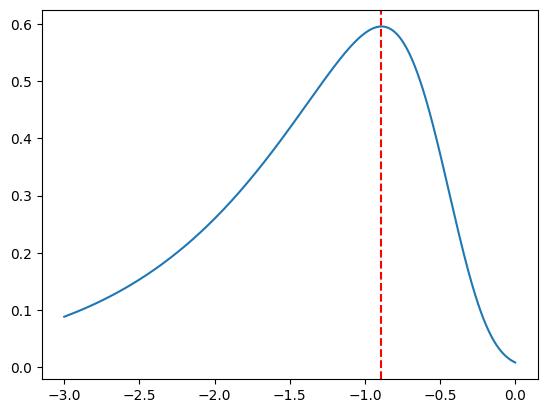

In [23]:
from scipy.special import jn_zeros
n=100
jn_zero = jn_zeros(0, n)
def dwell(t):
    return 4*np.sum(np.exp(-jn_zero[None,:]**2*t[:,None]),axis=1)
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
x_max=x[np.argmax(y)]
print("Maximum dwell time at log10(t) =", x_max)
plt.plot(x,y , label="Dwell time")
plt.axvline(x_max, color='red', linestyle='--', label='Max dwell time')

In [24]:
import numpy as np
import time
from numba import jit

np.random.seed(seed=0)

@jit(nopython=True)
def shift(x):
    l = 2
    return (x + l) % (2 * l) - l

@jit(nopython=True)
def MC_wander(L_max=int(1/dt)):
    
    sigma = np.sqrt(2 * D * dt)
    
    # Initialize time
    t = 0.0

    # Define the initial state of the nanoparticle
    r = np.random.uniform(low=r_out - epsilon, high=r_out)
    theta = np.random.uniform(low=0.0, high=2*np.pi)
    z_min = well_z(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    
    shifted_x = shift(np.array([x]))[0]
    shifted_y = shift(np.array([y]))[0]
    radius = np.sqrt(shifted_x**2 + shifted_y**2)
    
    # Initialize tracking arrays
    dwell_track = np.zeros(L_max)
    enter_track = np.zeros((L_max, 2))
    leave_track = np.zeros((L_max, 2))
    
    # IN = 1, OUT = 0
    if radius <= r_out:
        prev_in_well = 1
    else:
        prev_in_well = 0
    
    L = 0
    
    while L < L_max - 1:
        # Generate random steps using Wiener process
        dx = sigma * np.random.normal(0, 1)
        dy = sigma * np.random.normal(0, 1)
        dz = sigma * np.random.normal(0, 1)
        
        # Proposed new positions
        x = x + dx
        y = y + dy
        if ((z + dz) <= cap and (z + dz) >= w_h):
            z = z + dz
        
        # Get shifted coordinates for boundary checking
        shifted_x = shift(np.array([x]))[0]
        shifted_y = shift(np.array([y]))[0]
        
        
        # Update time
        t += dt
        radius = np.sqrt(shifted_x**2 + shifted_y**2)
        
        # Track well entries and exits
        if radius <= r_out:
            if prev_in_well == 0:
                L += 1
                enter_track[L] = np.array([shifted_x, shifted_y])
            dwell_track[L] += dt
            prev_in_well = 1
        else:
            if prev_in_well == 1:
                leave_track[L] = np.array([shifted_x, shifted_y])
                # Calculate angle difference with proper wrapping
            prev_in_well = 0
    
    return dwell_track, z

# Run the simulation
start_time = time.time()
dwell_track, z = MC_wander(L_max=int(1/dt))
end_time = time.time()
print(end_time - start_time)

3.4938642978668213


In [25]:
import numpy as np
import pandas as pd
from openpyxl import load_workbook
import xlsxwriter

In [26]:
with pd.ExcelWriter(path, engine='openpyxl') as writer:
	d = {'dwell_time': dwell_track[1:-1]}
	df = pd.DataFrame(data = d)
	df.to_excel(writer, index = True, sheet_name = 'dwell time')

In [ ]:
path0 = './Excel/1.005_30Hz_depth=0step_size=0.04dt=1e-06_angle_wander_MonteCarlo.xlsx'
data0 = pd.read_excel(path0, sheet_name='dwell time')
path1 = './Excel/1.005_30Hz_depth=0step_size=0.04dt=1e-05_angle_wander_MonteCarlo.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_30Hz_depth=0step_size=0.04dt=0.0001_angle_wander_MonteCarlo.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')

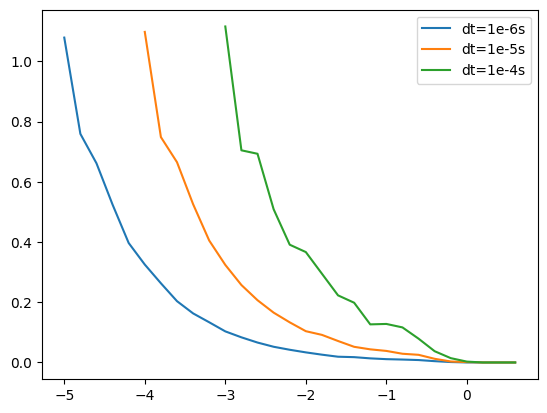

In [34]:
bin_edge0=np.arange(-5.1,0.9,0.2)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
Time=data0['dwell_time']
hist0,bin0= np.histogram(np.log10(Time), bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0,label='dt=1e-6s')
bin_edge1=np.arange(-4.1,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
Time=data1['dwell_time']
hist1,bin1= np.histogram(np.log10(Time), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist1,label='dt=1e-5s')
bin_edge2=np.arange(-3.1,0.9,0.2)
bin_center2 = (bin_edge2[:-1] + bin_edge2[1:]) / 2
Time=data2['dwell_time']
hist2,bin2= np.histogram(np.log10(Time), bins = bin_edge2,density=True)
plt.plot(bin_center2,hist2,label='dt=1e-4s')
plt.legend()